<a href="https://colab.research.google.com/github/thatGirlintheCorner/PythonCryptographyProjects/blob/main/Assignment2_PublicKeyCryptography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Assignment #2: Public Key Cryptography



Task #1: Implement Diffie-Hellman Key Exchange
For this task, we implemented two pairs of public and private keys. These pairs are held by Alice and Bob who utilize them to encrypt and decrypt so that they can send private messages back and forth.

In [ ]:
# Diffie-Hellman Code
from Crypto.Hash import SHA256
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import random

def main():
  # Create Public Parameters
  q = 0xB10B8F96A080E01DDE92DE5EAE5D54EC52C99FBCFB06A3C69A6A9DCA52D23B616073E28675A23D189838EF1E2EE652C013ECB4AEA906112324975C3CD49B83BFACCBDD7D90C4BD7098488E9C219A73724EFFD6FAE5644738FAA31A4FF55BCCC0A151AF5F0DC8B4BD45BF37DF365C1A65E68CFDA76D4DA708DF1FB2BC2E4A4371 # Prime Number
  a = 0xA4D1CBD5C3FD34126765A442EFB99905F8104DD258AC507FD6406CFF14266D31266FEA1E5C41564B777E690F5504F213160217B4B01B886A5E91547F9E2749F4D7FBD7D3B9A92EE1909D0D2263F80A76A6A24C087A091F531DBF0A0169B6A28AD662A4D18E73AFA32D779D5918D08BC8858F4DCEF97C2A24855E6EEB22B3B2E5 # Primitive root of q

  print(f"Diffie-Hellman Protocol (IETF 1024-bit parameters)")
  print("--------------------------------------------")

  # Alice creates private key
  alice_private = random.randint(1, q - 1)
  # Bob creates private key
  bob_private = random.randint(1, q - 1)

  # Alice computes public key
  alice_public = pow(a, alice_private, q)
  # Bob computes public key
  bob_public = pow(a, bob_private, q)

  print(f"Alice's private key (XA): {alice_private}")
  print(f"Alice's public key (YA): {alice_public}")
  print(f"Bob's private key (XB): {bob_private}")
  print(f"Bob's public key (YB): {bob_public}")

  # Alice and Bob exchange public keys

  # Alice computes secret shared key
  alice_shared = pow(bob_public, alice_private, q)
  byte_data = alice_shared.to_bytes(128, 'big')
  alice_hash = SHA256.new()
  alice_hash.update(byte_data)
  alice_key = alice_hash.digest()[:16]

  # Bob computes secret shared key
  bob_shared = pow(alice_public, bob_private, q)
  byte_data = bob_shared.to_bytes(128, 'big')
  bob_hash = SHA256.new()
  bob_hash.update(byte_data)
  bob_key = bob_hash.digest()[:16]

  print(f"Alice's computed shared secret: {alice_shared}")
  print(f"Bob's computed shared secret: {bob_shared}")
  print(f"Alice's derived key: {alice_hash.hexdigest()[:32]}")
  print(f"Bob's derived key: {bob_hash.hexdigest()[:32]}")

  same_key = True if (alice_key == bob_key) else False
  print(f"Alice and Bob have the same key: {same_key}\n")

  # Alice sends encrypted message
  msg_to_bob = "Hi Bob!"
  bytes_to_bob = msg_to_bob.encode("utf-8")
  number_padded_bytes_alice = (16 - len(bytes_to_bob))
  bytes_to_bob += bytes([number_padded_bytes_alice]) * number_padded_bytes_alice

  iv_alice = get_random_bytes(16)
  cipher_alice = AES.new(alice_key, AES.MODE_CBC, iv=iv_alice)
  ciphertext_to_bob = cipher_alice.encrypt(bytes_to_bob)

  print(f"Alice's message: {msg_to_bob}")
  print(f"Alice's IV: {iv_alice}")
  print(f"Alice's ciphertext: {ciphertext_to_bob}")

  # Bob decrypts Alice's message
  cipher_bob = AES.new(bob_key, AES.MODE_CBC, iv=iv_alice)
  msg_bob = cipher_bob.decrypt(ciphertext_to_bob)
  msg_bob = msg_bob[:(16 - number_padded_bytes_alice)]

  print(f"Bob's decrypted message: {msg_bob.decode("utf-8")}\n")

  # Bob sends encrypted message
  msg_to_alice = "Hi Alice!"
  bytes_to_alice = msg_to_alice.encode("utf-8")
  number_padded_bytes_bob = (16 - len(bytes_to_alice))
  bytes_to_alice += bytes([number_padded_bytes_bob]) * number_padded_bytes_bob

  iv_bob = get_random_bytes(16)
  cipher_bob = AES.new(bob_key, AES.MODE_CBC, iv=iv_bob)
  ciphertext_to_alice = cipher_bob.encrypt(bytes_to_alice)

  print(f"Bob's message: {msg_to_alice}")
  print(f"Bob's IV: {iv_bob}")
  print(f"Bob's ciphertext: {ciphertext_to_alice}")

  # Alice decrpyts Bob's message
  cipher_alice = AES.new(alice_key, AES.MODE_CBC, iv=iv_bob)
  msg_alice = cipher_alice.decrypt(ciphertext_to_alice)
  msg_alice = msg_alice[:(16 - number_padded_bytes_bob)]

  print(f"Alice's decrypted message: {msg_alice.decode("utf-8")}")

if __name__ == "__main__":
  main()


Diffie-Hellman Protocol (IETF 1024-bit parameters)
--------------------------------------------
Alice's private key (XA): 11753587319035256823400957033929385511974706232644942783532141595485663497533455255708708407610582173919708936610337535719795394414210836518901563209357896348418902793995503270078181220308332078417808226159390225127915364226439742053650426960138269816516835394052576670774987324277069955468242808416780621594
Alice's public key (YA): 66817354699517357021526443837944713005720245402767191500121491683060912725761295781081552740679736813410659978799445616855506366525517934202856127081113938332285090016137443903584082219261808664531172258615608664986131269225904560332505718801416767026341419471782877611587556468176740795821902026183872895071
Bob's private key (XB): 2555811322776415712462661147639040177892210202129139238451601970662269338629052111226867582437690461785505908000820868201582414752074014992889851454811764677667826330469447822829969645206405098618323984503211907

Task 1, Part 1: Output with Small Parameters

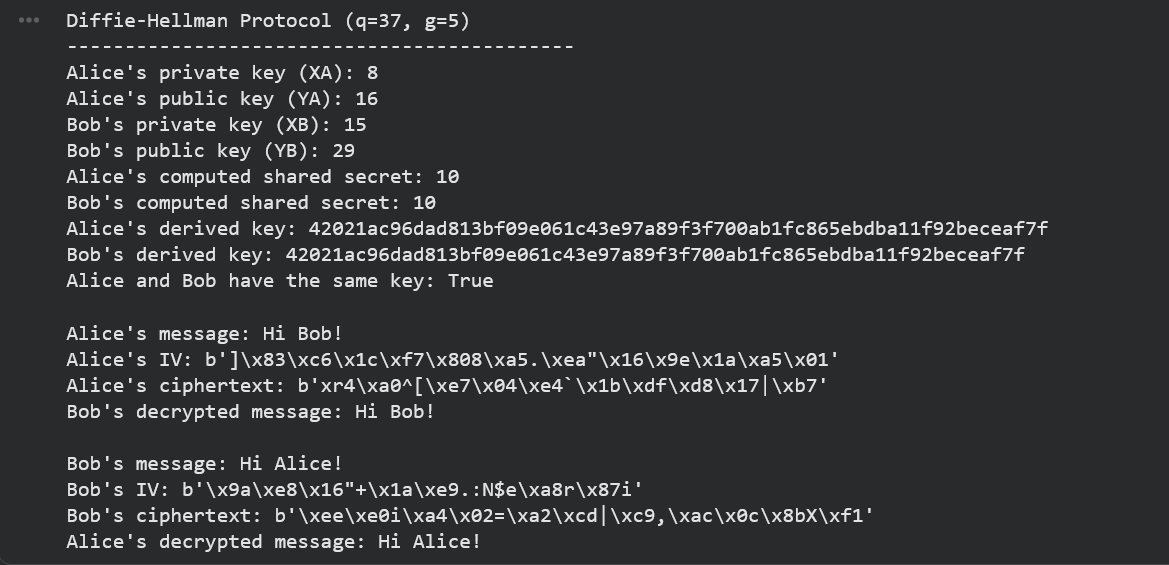

Task 1, Part 2: Output with Large Parameters

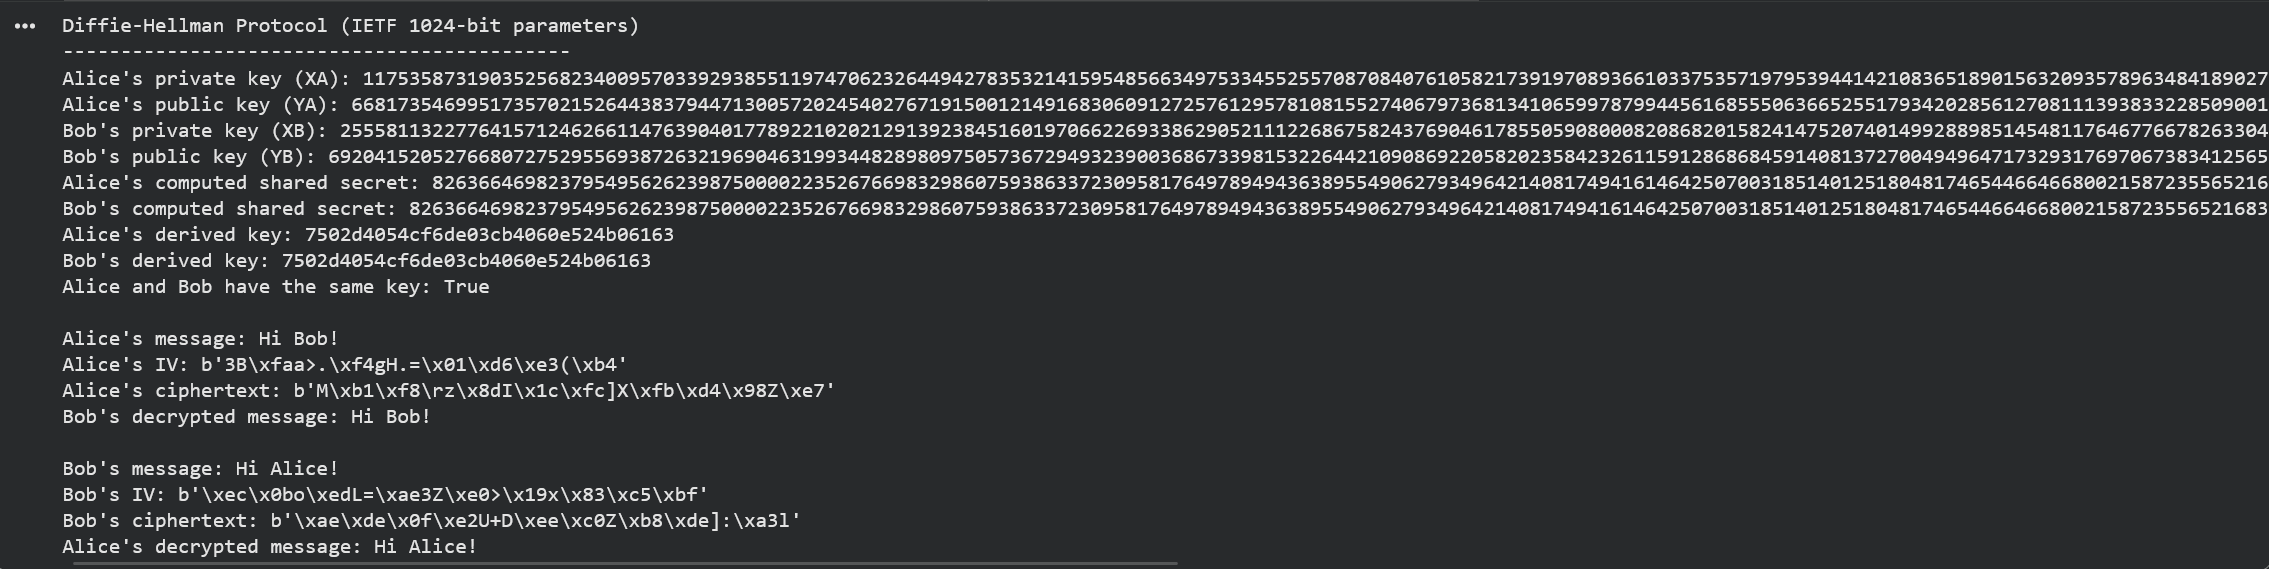

Task #2:  Implement MITM key fixing & negotiated groups
For this task, we implemented MITM attacks where Mallory, who is a bad actor, intercepts and modifies the parameters a or q to get a known shared key with both Alice and Bob. This allows Mallory to intercept and alter messages sent between Bob and Alice, who believe that they are communicating with each other, when in fact they are communicating with Mallory instead.

In [ ]:
# Diffie-Hellman Code
from Crypto.Hash import SHA256
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import random

def main(attack_type):
  # Create Public Parameters
  q = 0xB10B8F96A080E01DDE92DE5EAE5D54EC52C99FBCFB06A3C69A6A9DCA52D23B616073E28675A23D189838EF1E2EE652C013ECB4AEA906112324975C3CD49B83BFACCBDD7D90C4BD7098488E9C219A73724EFFD6FAE5644738FAA31A4FF55BCCC0A151AF5F0DC8B4BD45BF37DF365C1A65E68CFDA76D4DA708DF1FB2BC2E4A4371 # Prime Number
  a = 0xA4D1CBD5C3FD34126765A442EFB99905F8104DD258AC507FD6406CFF14266D31266FEA1E5C41564B777E690F5504F213160217B4B01B886A5E91547F9E2749F4D7FBD7D3B9A92EE1909D0D2263F80A76A6A24C087A091F531DBF0A0169B6A28AD662A4D18E73AFA32D779D5918D08BC8858F4DCEF97C2A24855E6EEB22B3B2E5 # Primitive root of q

  # initial alpha attack modification
  if attack_type == 'a':
    a = 1 # alpha can be set to 1, q, or q-1 for the math to work out.

  print(f"Diffie-Hellman Protocol (IETF 1024-bit parameters)")
  print("--------------------------------------------")

  # equivalent to Xa and Xb in the example -> private keys
  alice_private = random.randint(1, q - 1)
  bob_private = random.randint(1, q - 1)

  # Ya and Yb -> public keys
  alice_public = pow(a, alice_private, q)
  bob_public = pow(a, bob_private, q)

  print(f"Alice's private key (XA): {alice_private}")
  print(f"Alice's public key (YA): {alice_public}")
  print(f"Bob's private key (XB): {bob_private}")
  print(f"Bob's public key (YB): {bob_public}")

  # initial q attack modification
  if attack_type == 'q':
    alice_public, bob_public = q, q
    print(f"Alice's attacked public key: {alice_public}")
    print(f"Bob's attacked public key: {bob_public}", end='\n\n')

  # Alice computes secret shared key
  alice_shared = pow(bob_public, alice_private, q)
  byte_data = alice_shared.to_bytes(128, 'big')
  alice_hash = SHA256.new()
  alice_hash.update(byte_data)
  alice_key = alice_hash.digest()[:16]

  # Bob computes secret shared key
  bob_shared = pow(alice_public, bob_private, q)
  byte_data = bob_shared.to_bytes(128, 'big')
  bob_hash = SHA256.new()
  bob_hash.update(byte_data)
  bob_key = bob_hash.digest()[:16]


  print(f"Alice's computed shared secret: {alice_shared}")
  print(f"Bob's computed shared secret: {bob_shared}")
  print(f"Alice's derived key: {alice_hash.hexdigest()[:32]}")
  print(f"Bob's derived key: {bob_hash.hexdigest()[:32]}")
  # both of these shared secrets will alwyas be 0, as q^X mod q will always divide out without a remainder
  # so, Mallory can now derive that hash + digest using 0 as the shared secret

  if attack_type == 'q':
    mallory_shared = 0
    byte_data = mallory_shared.to_bytes(128, 'big')
    mallory_hash = SHA256.new()
    mallory_hash.update(byte_data)
    mallory_key = mallory_hash.digest()[:16]
    print(f"Mallory's derived key: {mallory_hash.hexdigest()[:32]}")
    print(f"All three have the same key: {alice_key == bob_key and bob_key == mallory_key}")
    # if this is true, mallory successfully determinted s
  elif attack_type == 'a':
    mallory_shared = 1 # only works when a = 1.
    byte_data = mallory_shared.to_bytes(128, 'big')
    mallory_hash = SHA256.new()
    mallory_hash.update(byte_data)
    mallory_key = mallory_hash.digest()[:16]
    print(f"Mallory's derived key: {mallory_hash.hexdigest()[:32]}")
    print(f"All three have the same key: {alice_key == bob_key and bob_key == mallory_key}")
    # if this is true, mallory successfully determinted s

  print()

  # Alice sends encrypted message
  msg_to_bob = "Hi Bob!"
  bytes_to_bob = msg_to_bob.encode("utf-8")
  number_padded_bytes_alice = (16 - len(bytes_to_bob))
  bytes_to_bob += bytes([number_padded_bytes_alice]) * number_padded_bytes_alice

  iv_alice = get_random_bytes(16)
  cipher_alice = AES.new(alice_key, AES.MODE_CBC, iv=iv_alice)
  ciphertext_to_bob = cipher_alice.encrypt(bytes_to_bob)

  print(f"Alice's message: {msg_to_bob}")
  print(f"Alice's IV: {iv_alice}")
  print(f"Alice's ciphertext: {ciphertext_to_bob}")

  # Bob decrypts Alice's message
  cipher_bob = AES.new(bob_key, AES.MODE_CBC, iv=iv_alice)
  msg_bob = cipher_bob.decrypt(ciphertext_to_bob)
  msg_bob = msg_bob[:(16 - number_padded_bytes_alice)]
  print(f"Bob's decrypted message: {msg_bob.decode("utf-8")}\n")

  if attack_type == 'q' or attack_type == 'a':
    # Mallory decrypts Alice's message
    cipher_mallory = AES.new(mallory_key, AES.MODE_CBC, iv=iv_alice)
    msg_mallory = cipher_mallory.decrypt(ciphertext_to_bob)
    msg_mallory = msg_mallory[:(16 - number_padded_bytes_alice)]
    print(f"Mallory's intercepted decrypted message: {msg_mallory.decode("utf-8")}\n")

  # Bob sends encrypted message
  msg_to_alice = "Hi Alice!"
  bytes_to_alice = msg_to_alice.encode("utf-8")
  number_padded_bytes_bob = (16 - len(bytes_to_alice))
  bytes_to_alice += bytes([number_padded_bytes_bob]) * number_padded_bytes_bob

  iv_bob = get_random_bytes(16)
  cipher_bob = AES.new(bob_key, AES.MODE_CBC, iv=iv_bob)
  ciphertext_to_alice = cipher_bob.encrypt(bytes_to_alice)

  print(f"Bob's message: {msg_to_alice}")
  print(f"Bob's IV: {iv_bob}")
  print(f"Bob's ciphertext: {ciphertext_to_alice}")

  # Alice decrpyts Bob's message
  cipher_alice = AES.new(alice_key, AES.MODE_CBC, iv=iv_bob)
  msg_alice = cipher_alice.decrypt(ciphertext_to_alice)
  msg_alice = msg_alice[:(16 - number_padded_bytes_bob)]
  print(f"Alice's decrypted message: {msg_alice.decode("utf-8")}\n")

  if attack_type == 'q' or attack_type == 'a':
    # Mallory decrypts Alice's message
    cipher_mallory = AES.new(mallory_key, AES.MODE_CBC, iv=iv_bob)
    msg_mallory = cipher_mallory.decrypt(ciphertext_to_alice)
    msg_mallory = msg_mallory[:(16 - number_padded_bytes_bob)]
    print(f"Mallory's intercepted decrypted message: {msg_mallory.decode("utf-8")}\n")

if __name__ == "__main__":
  main('a') # value can either be 'q' or 'a' to change those variables


Diffie-Hellman Protocol (IETF 1024-bit parameters)
--------------------------------------------
Alice's private key (XA): 44907932305424743997197200558155156877983688313241364821306381744682326911686348859790207490694697602535705565702694113296360250050453353993900454991172475569087790572442168686345075294822262366781145223087420982317864581343187709966567317910007600346313609144949444393335139747926476957894382206464158411927
Alice's public key (YA): 1
Bob's private key (XB): 81765172364391861401257646461279593167878048147166759672381372301831300771670441279393857329359917183379666697519701559114645571599960482602728480779931823624359871732784390060899730506164117728051990418090292559733903111512387939000358633798466427476206479186225616734149735814524560462003982336178501281611
Bob's public key (YB): 1
Alice's computed shared secret: 1
Bob's computed shared secret: 1
Alice's derived key: c4ab4be02b7d972e6fc8e5c0c730dccc
Bob's derived key: c4ab4be02b7d972e6fc8e5c0c730dccc
Mallory's de

Task #3:  Implement “textbook” RSA & MITM Key Fixing via Malleability
For this task, we implemented standard RSA for encryption and decryption of messages by having Alice and Bob create public, private key pairs.

In [ ]:
# Textbook RSA
import random

from Crypto.Util import number

def mod_pow(base, exponent, modulus):
  result = 1
  base = base % modulus
  while exponent > 0:
    if exponent % 2 == 1: # while the exponent is odd
      result = (result * base) % modulus
    exponent = exponent >> 1 # bit shift
    base = (base * base) % modulus
  return result

def mod_inverse(a, m):
  # computes the modular multiplicative inverse of a modulo m
  # IDK what this means in actual english lol
  def egcd(a,b):
    if a == 0: return (b, 0, 1)
    else:
      g,y,x = egcd(b % a, a)
      return (g, x - (b//a) * y, y)

  g, x, _ = egcd(a, m)
  if g != 1: raise ValueError("no such inverse")
  return x % m

if __name__ == "__main__":
  # given values
  # p and q should be 'variable length primes (up to 2048 bits)'
  # 17 and 11 are the fixed values for the example, but we can probably use something similar to task 1 for larger numbers
  # note: we can generate these primes using pycryptodome
  # p = number.getPrime(2048) <- this looks like the format
  print("Testing RSA Implementation")
  print("-------------------------")
  p = number.getPrime(2048)
  q = number.getPrime(2048)
  n = p * q
  phi = (p-1) * (q-1)
  e = 65537
  d = mod_inverse(e, phi)

  PU = (e,n)
  PR = (d,n)

  print("Generated RSA key pair. n has 2048 bits.\n")

  # encryption
  M = "Hello, World!"
  C = mod_pow(int.from_bytes(M.encode("utf-8"), "little"), e, n)
  print("Original message:", M)
  print("Encrypted (integer):", C)

  # decryption
  M_decrypted = mod_pow(C, d, n)
  print("Decrypted:", M_decrypted.to_bytes((M_decrypted.bit_length() + 7) // 8, 'little').decode('utf-8'))

  # encryption
  M = "RSA Encryption"
  C = mod_pow(int.from_bytes(M.encode("utf-8"), "little"), e, n)
  print("\nOriginal message:", M)
  print("Encrypted (integer):", C)

  # decryption
  M_decrypted = mod_pow(C, d, n)
  print("Decrypted:", M_decrypted.to_bytes((M_decrypted.bit_length() + 7) // 8, 'little').decode('utf-8'))

  # encryption
  M = "Cryptography is fun!"
  C = mod_pow(int.from_bytes(M.encode("utf-8"), "little"), e, n)
  print("\nOriginal message:", M)
  print("Encrypted (integer):", C)

  # decryption
  M_decrypted = mod_pow(C, d, n)
  print("Decrypted:", M_decrypted.to_bytes((M_decrypted.bit_length() + 7) // 8, 'little').decode('utf-8'))

  # encryption
  M = "Test message for RSA"
  C = mod_pow(int.from_bytes(M.encode("utf-8"), "little"), e, n)
  print("\nOriginal message:", M)
  print("Encrypted (integer):", C)

  # decryption
  M_decrypted = mod_pow(C, d, n)
  print("Decrypted:", M_decrypted.to_bytes((M_decrypted.bit_length() + 7) // 8, 'little').decode('utf-8'))

  print("\nAll valid messages were successfully encrypted and decrypted.")

Testing RSA Implementation
-------------------------
Generated RSA key pair. n has 2048 bits.

Original message: Hello, World!
Encrypted (integer): 123723789614452039892651354312683241109232793713528950071873204812802511759216084333515115913279108434487659818816429955809292858365462091402410086616275352569656345214443856143421653901489803555628317738618702843832388485240980822097094847095995500229065671145410585389116308937789916761740187372756340505593618395905013260947006971752862323184136114676735241293123861390988845051623667613821157701574858671245948467039011011016156378633903963527920858892898672460110753546565594907205954020782813414178989676656457616399661686849016473549787084217615740656836985333500965010696362542483291642373830563434535038026207755256350711954360858070325195104354700651984657649781905004652544818662954499282018091922703094321227457604495508824017809999890945840346752865478216316185961294915895174923269939099192807844942041988166323447017993739880310392378519

Task 3, Part 2a:
For this part of the task, we implemented a MITM attack to expose the malleabilty of RSA encryption. For this, Mallory intercepted ciphertext from Alice and chooses a factor of the symmetric key before sending a new ciphertext to Bob. Bob decrypts this, allowing Mallory to gain information needed to compute the true symmetric key and integrate herself between Alice and Bob's communications.

In [ ]:
import random
import math

from Crypto.Hash import SHA256
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes

from Crypto.Util import number

def mod_pow(base, exponent, modulus):
  result = 1
  base = base % modulus
  while exponent > 0:
    if exponent % 2 == 1: # while the exponent is odd
      result = (result * base) % modulus
    exponent = exponent >> 1 # bit shift
    base = (base * base) % modulus
  return result

def mod_inverse(a, m):
  # computes the modular multiplicative inverse of a modulo m
  # IDK what this means in actual english lol
  def egcd(a,b):
    if a == 0: return (b, 0, 1)
    else:
      g,y,x = egcd(b % a, a)
      return (g, x - (b//a) * y, y)

  g, x, _ = egcd(a, m)
  if g != 1: raise ValueError("no such inverse")
  return x % m

if __name__ == "__main__":
  print("Demonstrating RSA Encryption Malleability")
  print("------------------------------------------")

  # Alice generates an RSA key pair
  p = number.getPrime(2048)
  q = number.getPrime(2048)
  n = p * q
  phi = (p-1) * (q-1)
  e = 65537
  d = mod_inverse(e, phi)

  # Alice generates a shared key, s
  alice_shared = pow(e, d, q)
  byte_data = alice_shared.to_bytes(2048, 'big')
  alice_hash = SHA256.new()
  alice_hash.update(byte_data)
  s = alice_hash.digest()[:16]
  print(f"Alice's original symmetric key (s): {s}")

  # Alice encrypts the symmetric key
  c = mod_pow(int.from_bytes(s), e, n)
  print(f"Encrypted symmetric key (s): {c}\n")

  # Mallory Intercepts c from Alice
  # Attack Method #1
  # Mallory chooses a factor of s (the symmetric key)
  factor = 2
  # Mallory creates c'
  c_prime = (c * pow(factor, e, n)) % n
  print(f"Mallory's modified ciphertext (c'): {c_prime}\n")
  # Mallory sends c' to Bob

  # Bob decrypts c' to get s'
  s_prime = mod_pow(c_prime, d, n)
  print(f"Bob's decrypted value (s'): {s_prime}\n")

  # Mallory utilized s' to find s
  s_copy = (s_prime//2) % n
  length = int(math.ceil(s_copy.bit_length() / 8))
  s_copy = s_copy.to_bytes(length)
  print(f"Mallory's recovered symmetric key: {s_copy}\n")

  if s == s_copy:
    print("Attack successful: Mallory recovered the original symmetric key!\n")
  else:
    print("Attack failed\n")

  # Alice encrypts a message for Bob
  m = "Secret message from Bob to Alice"
  b = m.encode("utf-8")
  pad = len(b) % 16
  b += bytes([pad]) * pad

  iv_alice = get_random_bytes(16)
  cipher_alice = AES.new(s, AES.MODE_CBC, iv=iv_alice)
  c0 = cipher_alice.encrypt(b)

  # Alice sends c0 to Bob
  print(f"Bob's encrypted message (c0): {c0}")

  # Mallory intercepts c0
  # Mallory decrypts c0 using the s she calculated and reads m
  cipher_mallory = AES.new(s_copy, AES.MODE_CBC, iv=iv_alice)
  m_intercepted = cipher_mallory.decrypt(c0)
  m_intercepted = m_intercepted[:(len(m_intercepted) - pad)]
  print(f"Mallory's decrypted message: {m_intercepted}")

Demonstrating RSA Encryption Malleability
------------------------------------------
Alice's original symmetric key (s): b'\xbd\xae\xf0<b\xa5H#O\xffNQ\x83\x86\x10\xaf'
Encrypted symmetric key (s): 74226246933814348307237678993518468814110744146663294542346417510981591120163577872599990900368000846152308606889824635942086875311870579539377480031068190845035867665376790958667118578398598885074483532990485409351370215455995214442687413837953379516509325464018664869411922639581951388115851850679266650364147678858956123763933917416890198839456530925936845837707848808672738155329579251877226841602170778594638124078161093989118134550487386984524732401286979392355197300540611417556899994766504610473794342606897918110494224333633940075100804586009082981210411428093048410211151672267403768893954013415256823817543800900162413738410109517169490360042182939679460832981901854381848863253283683699581717590112612090011163994415681399158994839250530766749620415809951967712513540979361674103020251333656

Task 3, Part 2b:
For part b, we proved the malleability of RSA digital signatures with another MITM attack. This time, Mallory intercepts a message that has been signed by Alice. Mallory then creates and signs her own message, sucessfully integrating herself between Alice and Bob, making Bob think her signature is Alice's and Alice thinking that Mallory's signature is Bob's.

In [ ]:
# Task 3 Part 2b: RSA Signature Malleability Requirements
import random

from Crypto.Util import number

def mod_pow(base, exponent, modulus):
  result = 1
  base = base % modulus
  while exponent > 0:
    if exponent % 2 == 1: # while the exponent is odd
      result = (result * base) % modulus
    exponent = exponent >> 1 # bit shift
    base = (base * base) % modulus
  return result

def mod_inverse(a, m):
  # computes the modular multiplicative inverse of a modulo m
  # IDK what this means in actual english lol
  def egcd(a,b):
    if a == 0: return (b, 0, 1)
    else:
      g,y,x = egcd(b % a, a)
      return (g, x - (b//a) * y, y)

  g, x, _ = egcd(a, m)
  if g != 1: raise ValueError("no such inverse")
  return x % m

def verify(m, s, n):
  return True if (pow(s, e, n) == m) else False

if __name__ == "__main__":
  # Alice generates RSA key pairs
  print("Demonstrating RSA Signature Malleability")
  print("----------------------------------------")
  p = number.getPrime(2048)
  q = number.getPrime(2048)
  n = p * q
  phi = (p-1) * (q-1)
  e = 65537
  d = mod_inverse(e, phi)

  # Alice signs two messages using RSA key pairs
  m1 = 12345
  m2 = 67890
  print(f"Original message 1 (m1): {m1}")
  print(f"Original message 2 (m2): {m2}")

  s1 = pow(m1, d, n)
  s2 = pow(m2, d, n)
  print(f"Signature for m1: {s1}")
  print(f"Signature for m2: {s2}\n")

  # Alice publishes the message, signing pairs (m1, s1) and (m2, s2)
  print("Verifying original signatures:")
  v1 = verify(m1, s1, n)
  print(f"Signature 1 is valid: {v1}")
  v2 = verify(m2, s2, n)
  print(f"Signature 1 is valid: {v2}\n")

  # Mallory intercepts message, signing pairs

  # Mallory creates a new message
  m3 = (m1 * m2) % n
  print(f"Mallory's new message (m3 = m1 * m2 mod n): {m3}")

  # Mallory forges a new signiture
  s3 = (s1 * s2) % n
  print(f"Mallory's forged signature for m3: {s3}\n")

  # Mallory sends the new message, signature pair (m3, s3) to the verifier

  # Verifier verifies the forged signature
  print("Verifying Mallory's forged signature:")
  v3 = verify(m3, s3, n)
  print(f"Signature 3 is valid: {v3}\n")
  if v3:
    print("Attack successful: Mallory created a valid signature for a new message!")
  else:
    print("Attack failed")

Demonstrating RSA Signature Malleability
----------------------------------------
Original message 1 (m1): 12345
Original message 2 (m2): 67890
Signature for m1: 2957585116451505916596057685233313595457420298293532224665374745863531672312768968372561666151003363590486884235908220096013617859339761333837047585494552491713093248479580529461801564641358488762886493881948518629407461555600516481889654780823386666928021636156980680405221169336455643869494477322098458822305287716055551415331870415777339676366383320341844302214367561533817742102100120516322366822481656339805167381580752309029997276868347206608467617772856536011611396811116032144735758580387207789115768713923848671353484515705945914904559127591853126692539719760935870730641373735874591436649353623045993091762586623919950515855265913451120601684766904052723971940659828185834081127902582937516056183843175790428298170808662188200334691674721735774587103653620967554198104546042096968079781206349175278150737099234998531123945806196

Questions:
1. For task 1, how hard would it be for an adversary to solve the Diffie Hellman
Problem (DHP) given these parameters? What strategy might the adversary
take?

Given the small parameters provided for DHP in the first part of task 1, it wouldn't be esspecially hard for an adversary to solve. This is because even though DHP relies on discrete logarithms which are very difficult to solve, with small numbers, they can be broken in a reasonable amount of time. Because of the size of the parameters, the DHP can be broken with brute force or using a man-in-the-middle attack during the key exchange.

2. For task 1, would the same strategy used for the tiny parameters work for the
large values of q and alpha? Why or why not?

For the second part of task 1, brute force would not work on the DHP as the numbers used for q and alpha are simply too large. This means that the math required to break solve it is too difficult and requires too much computational power to be essentially impossible. For these kinds of more realistic values, the only way to break the DHP would be to perform a man-in-the-middle attack on the key exchange as breaking the keys themselves is not an option.

3. For task 2, why were these attacks possible? What is necessary to prevent it?

These attacks were possible due to the fact that Alice and Bob couldn't tell that the messages had been tampered with (a lack of integrity). Therefore, Mallory was able to step in the middle to change how those messages worked. So, adding a form of integrity, like hashing, would be an important measure to add to this system. Alternatively, there could be some digital sigunature method to ensure that you're receiving the message from the person that you expected.

4. For task 3 part 1, while it’s very common for many people to use the same
value for e in their key (common values are 3, 7, 216+1), it is very bad if two
people use the same RSA modulus n. Briefly describe why this is, and what
the ramifications are.

If two parties have the same RSA modulus n, then they used the same prime pair, (p, q). This means that the secret key of one party can be deduced by the other party as they can calculate phi which allows them to use the mathematical relationship between e, d, and phi to calculate d, the secret key, and break the encryption on any messages being sent by the first party.